## Dag 3 16/09

Doelen:
* Nieuwe metingen doen met verbeterd plan
* Betere data in grafiek plotten

De volgende code is wat uit vorige opdracht is gebleken handig voor de data-analyse

In [218]:
#inladen van enkele nuttige libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks


In [219]:
df = pd.read_csv("", skiprows=12, names=["Time", "Voltage"])
#Inladen data

Times = df["Time"]
Voltage = df["Voltage"]

A0 = max(Voltage)
t_A0 = np.argmax(Voltage)
#Max en daarmee start amplitude vinden

r = 0.38e-3 #straal draad
L = 0.25 #Spanlengte
opp = ((r)**2)*np.pi
m = opp * 7900 * L
#Berekenen van de massa op basis van de straal en de spanlengte



Clean_Times = Times[t_A0:]-Times[t_A0]
Clean_Voltage = Voltage[t_A0:]

Low_Voltage = Clean_Voltage[30000:] #Ingeschat op basis van wanneer de harmonische trilling begint
Low_Times = Clean_Times[30000:]

peaks_high, properties_high = find_peaks(Voltage, prominence=0.007) #Alleen de relevante pieken vinden


Fit_Times1 = Times[peaks_high]-Times[t_A0]
Fit_Times1 = Fit_Times1[15:]
Fit_Voltage1 = abs(Voltage[peaks_high])
Fit_Voltage1 = Fit_Voltage1[15:]

def Ampfunc(t, A_0, wrijvingco):
    return A_0*(np.e**( (-1*wrijvingco*t)/(2*m) ))
val, cov = curve_fit(Ampfunc, Fit_Times1, Fit_Voltage1, p0=[Voltage[t_A0+10], 0.0015])
print(val, cov)


plt.show()
plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")

plt.plot(Clean_Times, Clean_Voltage, 'g', label="Voltagegrafiek")
plt.plot(Fit_Times1, Fit_Voltage1,'r', label="peaks van de voltagegrafiek")
plt.plot(Fit_Times1, Ampfunc(Fit_Times1, val[0], val[1]), 'k', label='gefitte functie')
plt.savefig('Meting_2.png')

plt.legend()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: ''

Op basis van de resultaten vorige keer hebben we besloten om onder andere de functie waarvoor we fitten aan te passen van:
$$ A(t) = A_0 e^{\frac{\lambda t}{2m}} $$ naar: $$ A(t) = A_{rest} + A_0 e^{\frac{\lambda t}{2m}} $$
Hier is $A_{rest}$ de term die we toekennen aan de niet uitgedempte spanning. De functie in pyhton wordt dan als volgt.

In [249]:
def Ampfunc(t, wrijvingco, A_rest, A_0):
    return A_rest + A_0*(np.e**( (-1*wrijvingco*t)/(2*m) ))


<img src="Setup_sig-16-09.png" width="900" height="500" alt="Beschrijving">

waarde van de wrijvingscoeficient is [0.00096511 0.00175497 0.00998461]


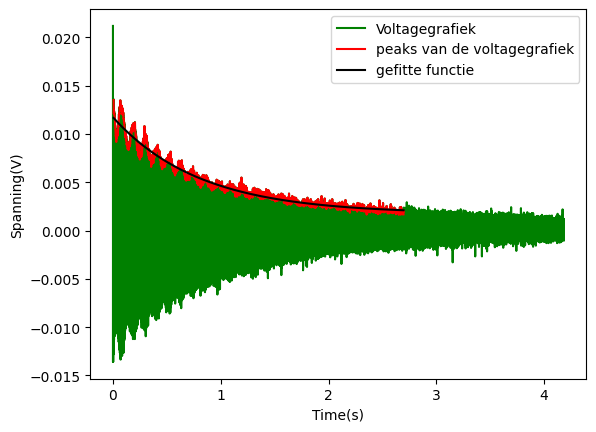

In [250]:
df = pd.read_csv("Data1_05mm.csv", skiprows=12, names=["Time", "Voltage"])
#Inladen data

Times = df["Time"]
Voltage = df["Voltage"]

A0 = max(Voltage)
t_A0 = np.argmax(Voltage)
#Max en daarmee start amplitude vinden

r = 0.25e-3 #straal draad
L = 0.25 #Spanlengte
opp = ((r)**2)*np.pi
m = opp * 7900 * L
#Berekenen van de massa op basis van de straal en de spanlengte
lambdas = []
u = []
#aanmaken lege arrays van de lambda's en de onzekerheden om de gevonden waardes erin te kunnen zetten.


Clean_Times = Times[t_A0:]-Times[t_A0]
Clean_Voltage = Voltage[t_A0:]

Low_Voltage = Clean_Voltage[30000:] #Ingeschat op basis van wanneer de harmonische trilling begint
Low_Times = Clean_Times[30000:]

peaks_high, properties_high = find_peaks(Voltage, prominence=0.003) #Alleen de relevante pieken vinden


Fit_Times1 = Times[peaks_high]-Times[t_A0]
Fit_Times1 = Fit_Times1[15:]
Fit_Times1 = Fit_Times1[:1700]
Fit_Voltage1 = abs(Voltage[peaks_high])
Fit_Voltage1 = Fit_Voltage1[15:]
Fit_Voltage1 = Fit_Voltage1[:1700]


val1, cov1 = curve_fit(Ampfunc, Fit_Times1, Fit_Voltage1, p0=[ 0.0015, Voltage[t_A0+10], Voltage[len(Times) - t_A0]])
print('waarde van de wrijvingscoeficient is', val1)

plt.show()
plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")

plt.plot(Clean_Times, Clean_Voltage, 'g', label="Voltagegrafiek")
plt.plot(Fit_Times1, Fit_Voltage1,'r', label="peaks van de voltagegrafiek")
plt.plot(Fit_Times1, Ampfunc(Fit_Times1, val1[0], val1[1], val1[2]), 'k', label='gefitte functie')
plt.legend()
plt.savefig('Meting_1.png')


plt.show()

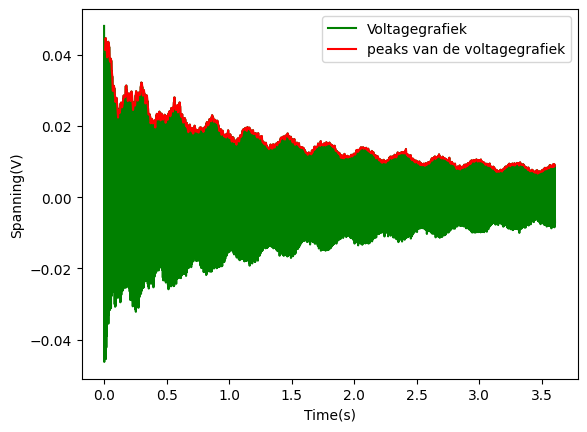

In [234]:
df = pd.read_csv("Data1_076mm.csv", skiprows=12, names=["Time", "Voltage"])
#Inladen data

Times = df["Time"]
Voltage = df["Voltage"]

A0 = max(Voltage)
t_A0 = np.argmax(Voltage)
#Max en daarmee start amplitude vinden

r = 0.38e-3 #straal draad
L = 0.25 #Spanlengte
opp = ((r)**2)*np.pi
m = opp * 7900 * L

Clean_Times = Times[t_A0:]-Times[t_A0]
Clean_Voltage = Voltage[t_A0:]

Low_Voltage = Clean_Voltage[40000:] #Ingeschat op basis van wanneer de harmonische trilling begint
Low_Times = Clean_Times[40000:]

peaks_high, properties_high = find_peaks(Voltage, prominence=0.01) #Alleen de relevante pieken vinden


Fit_Times1 = Times[peaks_high]-Times[t_A0]
Fit_Times1 = Fit_Times1[2:]
Fit_Voltage1 = abs(Voltage[peaks_high])
Fit_Voltage1 = Fit_Voltage1[2:]



plt.show()
plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")

#plt.plot(Times, Voltage, 'b')
plt.plot(Clean_Times, Clean_Voltage, 'g', label="Voltagegrafiek")
plt.plot(Fit_Times1, Fit_Voltage1,'r', label="peaks van de voltagegrafiek")
#plt.plot(Fit_Times1, Ampfunc(Fit_Times1, val[0], val[1], val[2]), 'k', label='gefitte functie')
plt.legend()
plt.savefig('Meting_2.png')


plt.show()

Trilling deed het niet, na vervangen onderdelen opstelling kregen we deze meting:

0.0008959508088772733
waarde van de wrijvingscoeficient is [0.00150314 0.01470214 0.04132894]


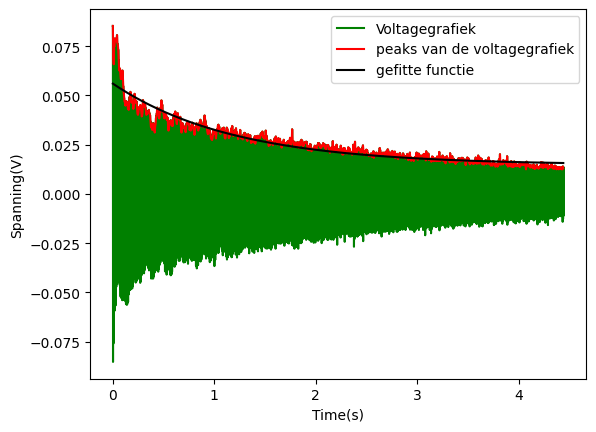

In [254]:
df = pd.read_csv("Data2_076mm.csv", skiprows=12, names=["Time", "Voltage"])
#Inladen data

Times = df["Time"]
Voltage = df["Voltage"]

A0 = max(Voltage)
t_A0 = np.argmax(Voltage)
#Max en daarmee start amplitude vinden

r = 0.38e-3 #straal draad
L = 0.25 #Spanlengte
opp = ((r)**2)*np.pi
m = opp * 7900 * L
print(m)

Clean_Times = Times[t_A0:]-Times[t_A0]
Clean_Voltage = Voltage[t_A0:]

Low_Voltage = Clean_Voltage[50000:] #Ingeschat op basis van wanneer de harmonische trilling begint
Low_Times = Clean_Times[50000:]

peaks_high, properties_high = find_peaks(Voltage, prominence=0.01) #Alleen de relevante pieken vinden


Fit_Times1 = Times[peaks_high]-Times[t_A0]
Fit_Times1 = Fit_Times1[21:]
Fit_Voltage1 = abs(Voltage[peaks_high])
Fit_Voltage1 = Fit_Voltage1[21:]

val3, cov3 = curve_fit(Ampfunc, Fit_Times1, Fit_Voltage1, maxfev=5000)
#, p0=[Voltage[len(Times) - t_A0], Voltage[t_A0+20], 0.015]
print('waarde van de wrijvingscoeficient is', val3)


plt.show()
plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")

#plt.plot(Times, Voltage, 'b')
plt.plot(Clean_Times, Clean_Voltage, 'g', label="Voltagegrafiek")
plt.plot(Fit_Times1, Fit_Voltage1,'r', label="peaks van de voltagegrafiek")
plt.plot(Fit_Times1, Ampfunc(Fit_Times1, val3[0], val3[1], val3[2]), 'k', label='gefitte functie')
plt.legend()
plt.savefig('Meting_3.png')




plt.show()

0.0015511613727099602
waarde van de wrijvingscoeficient is [0.00150314 0.01470214 0.04132894]


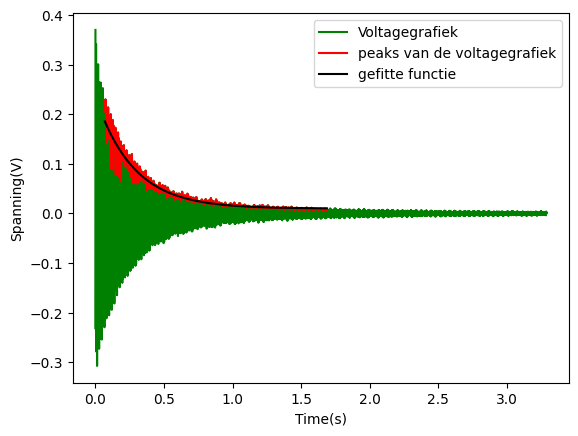

In [245]:
df = pd.read_csv("Data1_1mm.csv", skiprows=12, names=["Time", "Voltage"])
#Inladen data

Times = df["Time"]
Voltage = df["Voltage"]

A0 = max(Voltage)
t_A0 = np.argmax(Voltage)
#Max en daarmee start amplitude vinden

r = 0.5e-3 #straal draad
L = 0.25 #Spanlengte
opp = ((r)**2)*np.pi
m = opp * 7900 * L
print(m)

Clean_Times = Times[t_A0:]-Times[t_A0]
Clean_Voltage = Voltage[t_A0:]
Low_Voltage = Clean_Voltage[50000:] #Ingeschat op basis van wanneer de harmonische trilling begint
Low_Times = Clean_Times[50000:]
peaks_high, properties_high = find_peaks(Voltage, prominence=0.01) #Alleen de relevante pieken vinden


Fit_Times1 = Times[peaks_high]-Times[t_A0]
Fit_Times1 = Fit_Times1[21:]
Fit_Times1 = Fit_Times1[:400]
Fit_Voltage1 = abs(Voltage[peaks_high])
Fit_Voltage1 = Fit_Voltage1[21:]
Fit_Voltage1 = Fit_Voltage1[:400]

val4, cov4 = curve_fit(Ampfunc, Fit_Times1, Fit_Voltage1, maxfev=5000)
#, p0=[Voltage[len(Times) - t_A0], Voltage[t_A0+20], 0.015]
print('waarde van de wrijvingscoeficient is', val3)



plt.show()
plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")

#plt.plot(Times, Voltage, 'b')
plt.plot(Clean_Times, Clean_Voltage, 'g', label="Voltagegrafiek")
plt.plot(Fit_Times1, Fit_Voltage1,'r', label="peaks van de voltagegrafiek")
plt.plot(Fit_Times1, Ampfunc(Fit_Times1, val4[0], val4[1], val4[2]), 'k', label='gefitte functie')
plt.legend()
plt.savefig('Meting_4.png')



plt.show()

[0.00056009 0.00557251 0.02018012]


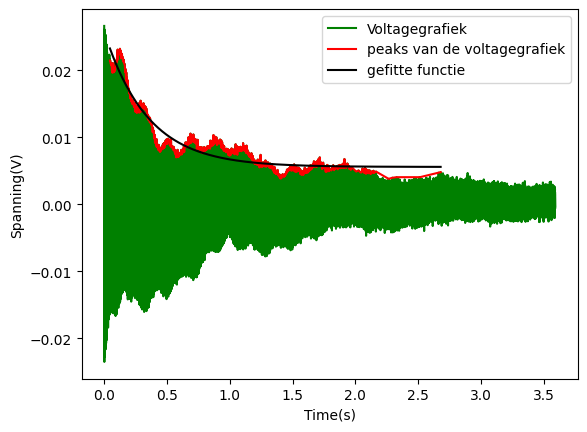

In [225]:
df = pd.read_csv("Data2_025mm.csv", skiprows=12, names=["Time", "Voltage"])
#Inladen data

Times = df["Time"]
Voltage = df["Voltage"]

A0 = max(Voltage)
t_A0 = np.argmax(Voltage)
#Max en daarmee start amplitude vinden

r = 0.125e-3 #straal draad
L = 0.25 #Spanlengte
opp = ((r)**2)*np.pi
m = opp * 7900 * L


Clean_Times = Times[t_A0:]-Times[t_A0]
Clean_Voltage = Voltage[t_A0:]
Low_Voltage = Clean_Voltage[50000:] #Ingeschat op basis van wanneer de harmonische trilling begint
Low_Times = Clean_Times[50000:]
peaks_high, properties_high = find_peaks(Voltage, prominence=0.008) #Alleen de relevante pieken vinden


Fit_Times1 = Times[peaks_high]-Times[t_A0]
Fit_Times1 = Fit_Times1[21:]
Fit_Times1 = Fit_Times1[:4000]
Fit_Voltage1 = abs(Voltage[peaks_high])
Fit_Voltage1 = Fit_Voltage1[21:]
Fit_Voltage1 = Fit_Voltage1[:4000]

val4, cov4 = curve_fit(Ampfunc, Fit_Times1, Fit_Voltage1, maxfev=5000, p0=[0.015, 0.005,0.02])
#, p0=[Voltage[len(Times) - t_A0], Voltage[t_A0+20], 0.015]
print(val4)


plt.show()
plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")

#plt.plot(Times, Voltage, 'b')
plt.plot(Clean_Times, Clean_Voltage, 'g', label="Voltagegrafiek")
plt.plot(Fit_Times1, Fit_Voltage1,'r', label="peaks van de voltagegrafiek")
plt.plot(Fit_Times1, Ampfunc(Fit_Times1, val4[0], val4[1], val4[2]), 'k', label='gefitte functie')
plt.legend()
plt.savefig('Meting_5.png')



plt.show()

In [226]:
def Ampfunc(t, A_rest, A_0, wrijvingco):
    return A_rest + A_0 * np.exp(-wrijvingco * t / (2*m))
data = {}

for i in range(1, 6):
    df = pd.read_csv(
        f"Data{i}_1mm.csv",
        skiprows=12,
        names=["Time", "Voltage"]
    )

    Times = df["Time"].to_numpy()
    Voltage = df["Voltage"].to_numpy()

    A0 = np.max(Voltage)
    t_A0 = np.argmax(Voltage)

    Clean_Times = Times[t_A0:] - Times[t_A0]
    Clean_Voltage = Voltage[t_A0:]
    Low_Voltage = Clean_Voltage[50000:]
    Low_Times = Clean_Times[50000:]


    peaks_high, properties_high = find_peaks( Voltage, prominence=0.01)

    Fit_Times = Times[peaks_high] - Times[t_A0]
    Fit_Times = Fit_Times[21:400]

    Fit_Voltage = np.abs(Voltage[peaks_high])
    Fit_Voltage = Fit_Voltage[21:400]

    val, cov = curve_fit(
                                Ampfunc, Fit_Times, Fit_Voltage, p0=[0, Fit_Voltage[0], 0.01], 
                                bounds=([-np.inf, 0, 0], [np.inf, np.inf, np.inf]),maxfev=5000
                                )
    val = np.asarray(val)
    cov = np.asarray(cov)

    data[i] = {
        "df": df,
        "Times": Times,
        "Voltage": Voltage,
        "A0": A0,
        "t_A0": t_A0,
        "Clean_Times": Clean_Times,
        "Clean_Voltage": Clean_Voltage,
        "Low_Times": Low_Times,
        "Low_Voltage": Low_Voltage,
        "peaks_high": peaks_high,
        "Fit_Times": Fit_Times,
        "Fit_Voltage": Fit_Voltage,
        "val": val,
        "cov": cov,
    }
for i in range(1, 6):
    print(f"Measurement {i}: lambda = {data[i]['val'][2]}")

Measurement 1: lambda = 0.0007121739369877183
Measurement 2: lambda = 0.001012467211791913
Measurement 3: lambda = 0.0007257825457352398
Measurement 4: lambda = 0.0007017640354741326
Measurement 5: lambda = 0.0013545479760476002


In [227]:
data_076mm = {}

for i in range(1, 6):
    df = pd.read_csv(
        f"Data{i}_076mm.csv",
        skiprows=12,
        names=["Time", "Voltage"]
    )

    Times = df["Time"].to_numpy()
    Voltage = df["Voltage"].to_numpy()

    A0 = np.max(Voltage)
    t_A0 = np.argmax(Voltage)

    Clean_Times = Times[t_A0:] - Times[t_A0]
    Clean_Voltage = Voltage[t_A0:]
    Low_Voltage = Clean_Voltage[50000:]
    Low_Times = Clean_Times[50000:]


    peaks_high, properties_high = find_peaks( Voltage, prominence=0.01)

    Fit_Times = Times[peaks_high] - Times[t_A0]
    Fit_Times = Fit_Times[21:]

    Fit_Voltage = np.abs(Voltage[peaks_high])
    Fit_Voltage = Fit_Voltage[21:]

    val, cov = curve_fit(
                                Ampfunc, Fit_Times, Fit_Voltage, p0=[0, Fit_Voltage[0], 0.01], 
                                bounds=([-np.inf, 0, 0], [np.inf, np.inf, np.inf]),maxfev=5000
                                )
    val = np.asarray(val)
    cov = np.asarray(cov)

    data_076mm[i] = {
        "df": df,
        "Times": Times,
        "Voltage": Voltage,
        "A0": A0,
        "t_A0": t_A0,
        "Clean_Times": Clean_Times,
        "Clean_Voltage": Clean_Voltage,
        "Low_Times": Low_Times,
        "Low_Voltage": Low_Voltage,
        "peaks_high": peaks_high,
        "Fit_Times": Fit_Times,
        "Fit_Voltage": Fit_Voltage,
        "val": val,
        "cov": cov,
    }
for i in range(1, 6):
    print(f"Measurement {i}: lambda = {data_076mm[i]['val'][2]}")

Measurement 1: lambda = 0.00012369352328860976
Measurement 2: lambda = 0.00016265241309487745
Measurement 3: lambda = 0.00020441936776081706
Measurement 4: lambda = 0.00026043154240061627
Measurement 5: lambda = 0.00027100695297502074


In [228]:
data_025mm = {}

for i in range(2, 6):
    df = pd.read_csv(
        f"Data{i}_025mm.csv",
        skiprows=12,
        names=["Time", "Voltage"]
    )

    Times = df["Time"].to_numpy()
    Voltage = df["Voltage"].to_numpy()

    A0 = np.max(Voltage)
    t_A0 = np.argmax(Voltage)

    Clean_Times = Times[t_A0:] - Times[t_A0]
    Clean_Voltage = Voltage[t_A0:]
    Low_Voltage = Clean_Voltage[50000:]
    Low_Times = Clean_Times[50000:]


    peaks_high, properties_high = find_peaks( Voltage, prominence=0.01)

    Fit_Times = Times[peaks_high] - Times[t_A0]
    Fit_Times = Fit_Times[21:1700]

    Fit_Voltage = np.abs(Voltage[peaks_high])
    Fit_Voltage = Fit_Voltage[21:1700]

    val, cov = curve_fit(
                                Ampfunc, Fit_Times, Fit_Voltage, p0=[0.015, 0.005,0.02], 
                                bounds=([-np.inf, 0, 0], [np.inf, np.inf, np.inf]),maxfev=5000
                                )
    val = np.asarray(val)
    cov = np.asarray(cov)

    data_025mm[i] = {
        "df": df,
        "Times": Times,
        "Voltage": Voltage,
        "A0": A0,
        "t_A0": t_A0,
        "Clean_Times": Clean_Times,
        "Clean_Voltage": Clean_Voltage,
        "Low_Times": Low_Times,
        "Low_Voltage": Low_Voltage,
        "peaks_high": peaks_high,
        "Fit_Times": Fit_Times,
        "Fit_Voltage": Fit_Voltage,
        "val": val,
        "cov": cov,
    }
for i in range(2, 6):
    print(f"Measurement {i}: lambda = {data_025mm[i]['val'][2]}")

Measurement 2: lambda = 0.0006291977891747504
Measurement 3: lambda = 0.0005135331255813543
Measurement 4: lambda = 0.0005074962742613529
Measurement 5: lambda = 0.00017952404074959405


In [229]:
data_06mm = {}

for i in range(1, 6):
    df = pd.read_csv(
        f"Data{i}_06mm.csv",
        skiprows=12,
        names=["Time", "Voltage"]
    )

    Times = df["Time"].to_numpy()
    Voltage = df["Voltage"].to_numpy()

    A0 = np.max(Voltage)
    t_A0 = np.argmax(Voltage)

    Clean_Times = Times[t_A0:] - Times[t_A0]
    Clean_Voltage = Voltage[t_A0:]
    Low_Voltage = Clean_Voltage[50000:]
    Low_Times = Clean_Times[50000:]


    peaks_high, properties_high = find_peaks( Voltage, prominence=0.01)

    Fit_Times = Times[peaks_high] - Times[t_A0]
    Fit_Times = Fit_Times[21:]

    Fit_Voltage = np.abs(Voltage[peaks_high])
    Fit_Voltage = Fit_Voltage[21:]

    val, cov = curve_fit(
                                Ampfunc, Fit_Times, Fit_Voltage, p0=[0, Fit_Voltage[0], 0.01], 
                                bounds=([-np.inf, 0, 0], [np.inf, np.inf, np.inf]),maxfev=5000
                                )
    val = np.asarray(val)
    cov = np.asarray(cov)

    data_06mm[i] = {
        "df": df,
        "Times": Times,
        "Voltage": Voltage,
        "A0": A0,
        "t_A0": t_A0,
        "Clean_Times": Clean_Times,
        "Clean_Voltage": Clean_Voltage,
        "Low_Times": Low_Times,
        "Low_Voltage": Low_Voltage,
        "peaks_high": peaks_high,
        "Fit_Times": Fit_Times,
        "Fit_Voltage": Fit_Voltage,
        "val": val,
        "cov": cov,
    }
for i in range(1, 6):
    print(f"Measurement {i}: lambda = {data_06mm[i]['val'][2]}")

Measurement 1: lambda = 0.00015428810485827775
Measurement 2: lambda = 0.00017264099953175432
Measurement 3: lambda = 0.03319018913059401
Measurement 4: lambda = 6.367709371397752e-08
Measurement 5: lambda = 5.515876593036737e-08


[0.39480632] [[0.00445241]]


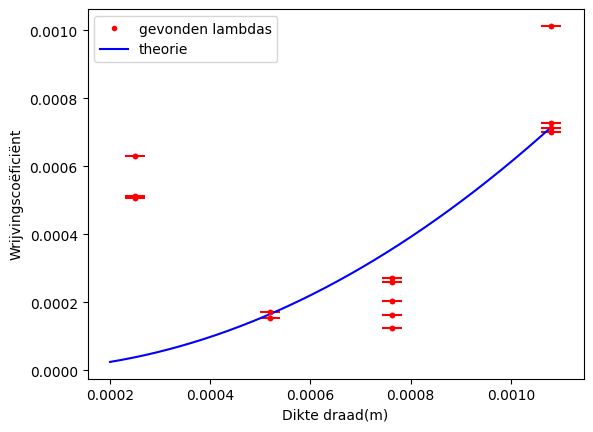

In [252]:
lambdas1 = []
u = []
for i in range(1, 5):
    lambdas1.append(data[i]['val'][2])
u.append(data[5]['val'][2]-data[1]['val'][2])
for i in range(1, 6):
    lambdas1.append(data_076mm[i]['val'][2])
u.append(data_076mm[5]['val'][2]-data_076mm[1]['val'][2])
for i in range(2, 5):
    lambdas1.append(data_025mm[i]['val'][2])
u.append(data_025mm[2]['val'][2]-data_025mm[4]['val'][2])
for i in range(1, 3):
    lambdas1.append(data_06mm[i]['val'][2])
u.append(data_06mm[2]['val'][2]-data_06mm[4]['val'][2])
dia_Draad = []
for i in range(1, 5):
    dia_Draad.append(1.08e-3)
for i in range(1, 6):
    dia_Draad.append(0.762e-3)
for i in range(2, 5):
    dia_Draad.append(0.25e-3)
for i in range(1, 3):
    dia_Draad.append(0.52e-3)

Theorie_dikte = np.array(np.linspace(0.2e-3, 1.08e-3, 1000))

def lambda_theorie(dia, C):
    return C*(((dia/2)**2)*np.pi)* 7900 * 0.25
val, cov = curve_fit(lambda_theorie, dia_Draad, lambdas1)
print(val, cov)
plt.figure()

plt.xlabel("Dikte draad(m)")
plt.ylabel("Wrijvingscoëficiënt")

plt.errorbar(dia_Draad, lambdas1,[0], [0.02e-3],  'r.')
plt.plot(dia_Draad, lambdas1, 'r.', label='gevonden lambdas')
plt.plot(Theorie_dikte, lambda_theorie(Theorie_dikte, val[0]), 'b', label="theorie")


plt.legend()
plt.savefig('Eind_grafiek.png')
plt.show()
